In [11]:
# To load the mnist data
import tensorflow
from keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential

# importing various types of hidden layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

# Adam optimizer for better LR and less loss
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

In [12]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

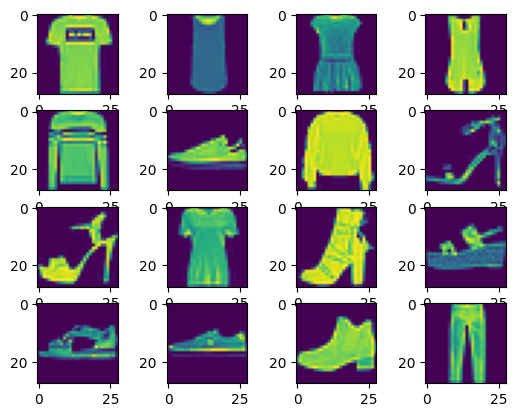

In [13]:
for i in range(1, 17):
    plt.subplot(4, 4, i)
    plt.imshow(X_train[i])
plt.show()

In [14]:
def model_CNN():
    
    models = Sequential()
    models.add(Conv2D(64, (5, 5), # (5x5 filter size) (64 number of filter)
                     padding='same', # no padding
                     activation= 'relu',
                     input_shape = (28, 28, 1))) # 28x28 grid, 1 channel
    models.add(MaxPooling2D(pool_size=(2, 2))) # decrease size of kernal by 1/2 so 14x14
    models.add(Conv2D(128, (5, 5),
                      padding='same',
                      activation='relu',))
    models.add(MaxPooling2D(pool_size=(2, 2)))
    models.add(Conv2D(256, (5, 5),
                      padding='same',
                      activation='relu'))
    models.add(MaxPooling2D(pool_size=(2, 2)))
    models.add(Flatten())
    models.add(Dense(256, activation='relu'))
    models.add(Dense(10, activation='softmax'))
    return models

In [15]:
model = model_CNN()
# compile the model (spelling corrected)
model.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,618,698 (6.17 MB)

 Trainable params: 1,618,698 (6.17 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train.astype(np.float32), y_train.astype(np.float32),
    epochs=10,
    steps_per_epoch=100,
    validation_split=0.33
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 92s 904ms/step - loss: 3.1437 - sparse_categorical_accuracy: 0.7165 - val_loss: 0.3870 - val_sparse_categorical_accuracy: 0.8647
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 91s 909ms/step - loss: 0.3443 - sparse_categorical_accuracy: 0.8759 - val_loss: 0.3484 - val_sparse_categorical_accuracy: 0.8750
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 91s 915ms/step - loss: 0.2828 - sparse_categorical_accuracy: 0.8968 - val_loss: 0.2863 - val_sparse_categorical_accuracy: 0.8968
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 95s 951ms/step - loss: 0.2507 - sparse_categorical_accuracy: 0.9078 - val_loss: 0.2821 - val_sparse_categorical_accuracy: 0.8990
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 91s 916ms/step - loss: 0.2273 - sparse_categorical_accuracy: 0.9144 - val_loss: 0.2753 - val_sparse_categorical_accuracy: 0.9024
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 870ms/step - loss: 0.1962 - sparse_categorical_accuracy: 0.9282 - val_loss: 0.2802 - val_sparse_categorical_acc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted label: trouser


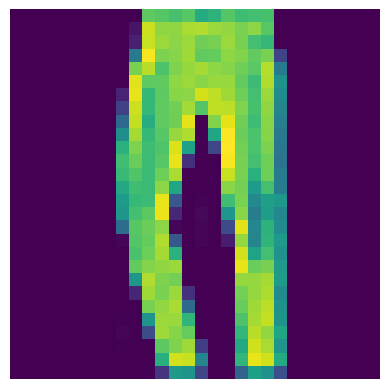

In [45]:
idx = 5

predictions = model.predict(X_test[idx:idx+1])
label = labels[np.argmax(predictions)]

print("Predicted label:", label)
plt.imshow(X_test[idx])
plt.axis("off")
plt.show()